In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve, confusion_matrix
import statsmodels.api as sm

Считывание файла

In [2]:
df_1 = pd.read_csv('Metrika_dannye_VRP_bez_summarnykh_pokazateley_new.csv', sep=';')
for col in df_1.columns[1:]:
    df_1[col] = df_1[col].astype(str).str.replace(' ', '').str.replace(',', '.').str.replace('%', '')
    df_1[col] = pd.to_numeric(df_1[col], errors='coerce')
df_1

,2024,"ВРП на душу населения, руб.","Численность рабочей силы, тыс. чел.","Инвестиции в основной капитал на душу населения, руб","Добыча полезных ископаемых + обрабатывающие производства в структуре ВРП, %","Доля городского населения в общей численности населения, %","Протяженность автомобильных дорог, км"
0,Белгородская область,1015794,813.2,160813,43,65,13609.0
1,Брянская область,636575,570.7,103513,22,70,10984.0
2,Владимирская область,743499,713.8,109385,38,78,10047.0
3,Воронежская область,757722,1218.4,156148,16,69,20622.0
4,Ивановская область,557302,487.4,81966,26,82,8160.0
...,...,...,...,...,...,...,...
80,Амурская область,1365680,407.0,1259571,18,68,9188.0
81,Магаданская область,3936320,78.3,771039,55,97,622.0
82,Сахалинская область,3665840,269.7,776403,56,83,2949.0
83,Еврейская автономная область,786448,76.0,234679,21,71,2009.0


**Выбросы**

Подсчет пропусков

In [3]:
df_1.isnull().sum()

2024                                                                           0
ВРП на душу населения, руб.                                                    0
Численность рабочей силы, тыс. чел.                                            0
Инвестиции в основной капитал на душу населения, руб                           0
Добыча полезных ископаемых + обрабатывающие производства в структуре ВРП, %    0
Доля городского населения в общей численности населения, %                     0
Протяженность автомобильных дорог, км                                          3
dtype: int64

Строки с пропусками

In [4]:
df_1[df_1.isnull().any(axis=1)]

,2024,"ВРП на душу населения, руб.","Численность рабочей силы, тыс. чел.","Инвестиции в основной капитал на душу населения, руб","Добыча полезных ископаемых + обрабатывающие производства в структуре ВРП, %","Доля городского населения в общей численности населения, %","Протяженность автомобильных дорог, км"
17,г. Москва,3103504,7218.5,614842,13,100,NaN
28,г.Санкт-Петербург,2301327,3258.5,276151,13,100,NaN
36,г. Севастополь,504990,298.7,180934,8,93,NaN


Удаление пропусков

In [5]:
df = df_1.dropna()

Боксплоты

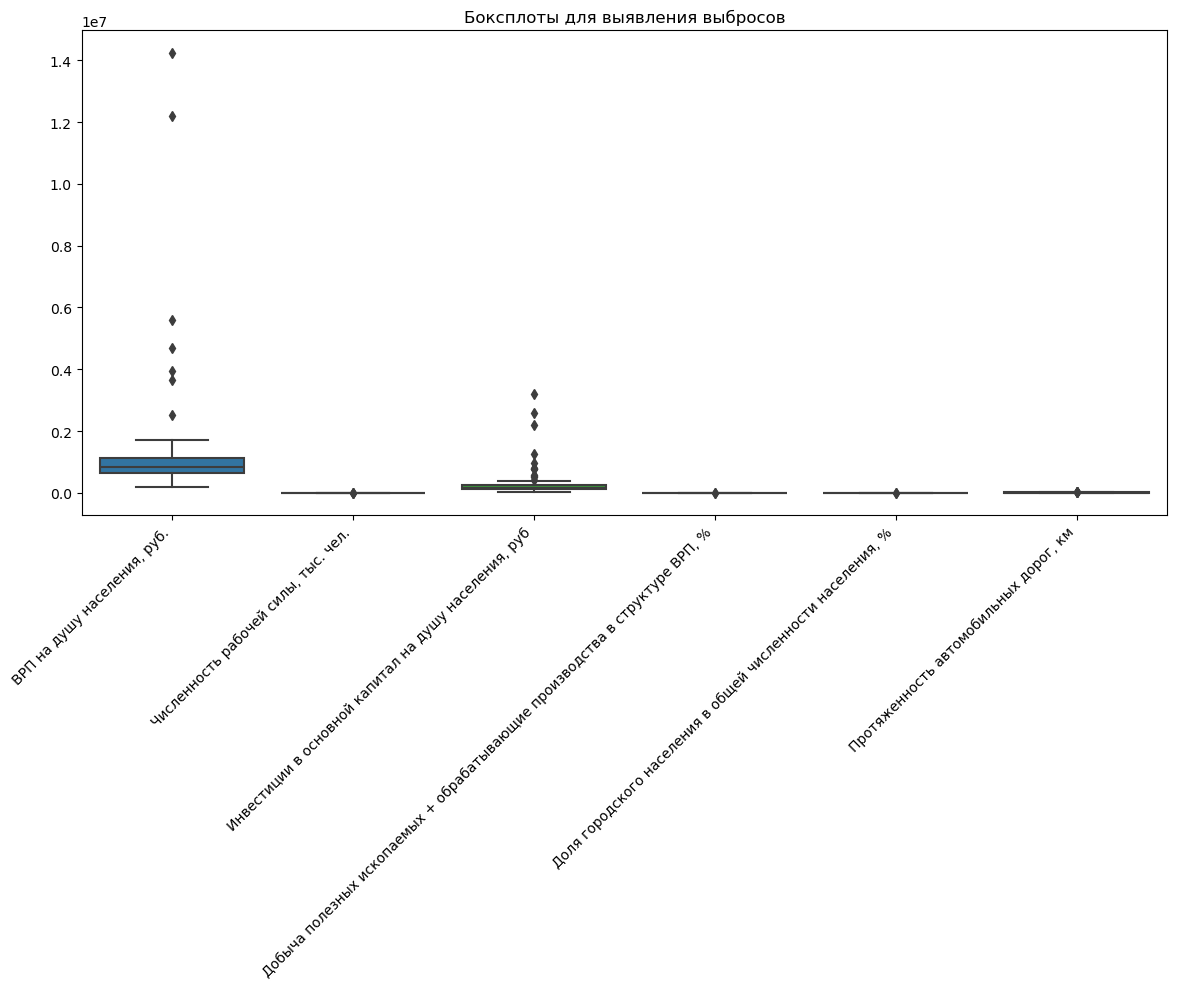

In [6]:
plt.figure(figsize=(12, 10))
sns.boxplot(data=df.select_dtypes(include=[np.number]))
plt.title("Боксплоты для выявления выбросов")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Строки с выбросами

In [7]:
df.nlargest(2, 'ВРП на душу населения, руб.')

,2024,"ВРП на душу населения, руб.","Численность рабочей силы, тыс. чел.","Инвестиции в основной капитал на душу населения, руб","Добыча полезных ископаемых + обрабатывающие производства в структуре ВРП, %","Доля городского населения в общей численности населения, %","Протяженность автомобильных дорог, км"
20,Ненецкий автономный округ,14250822,23.2,2596040,84,75,114.0
61,Ямало-Ненецкий автономный округ,12196003,299.8,3187869,77,85,1657.0


In [8]:
df = df.drop(df.nlargest(2, 'ВРП на душу населения, руб.').index)

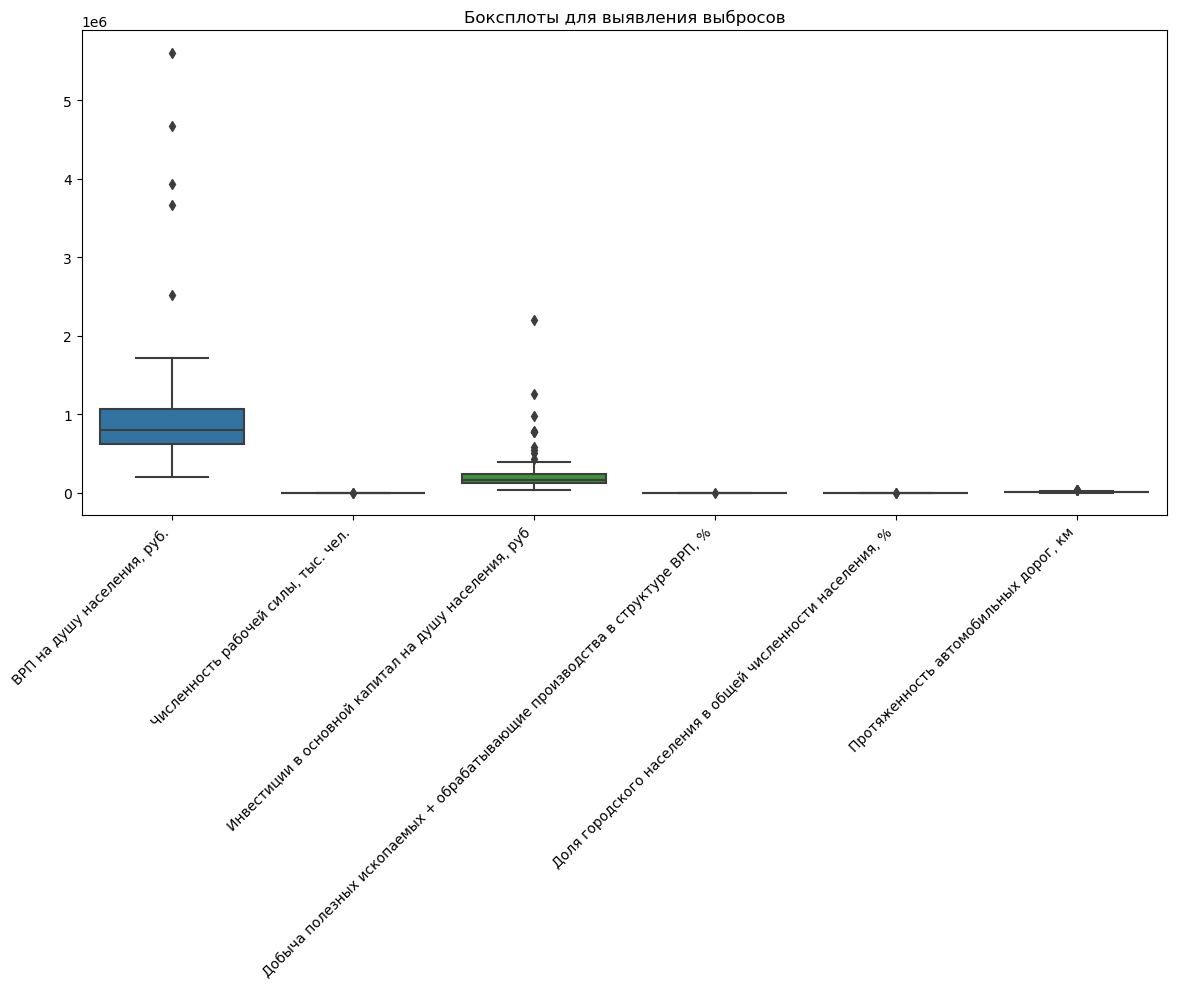

In [9]:
plt.figure(figsize=(12, 10))
sns.boxplot(data=df.select_dtypes(include=[np.number]))
plt.title("Боксплоты для выявления выбросов")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Описательная статистика**

In [10]:
df.describe()

,"ВРП на душу населения, руб.","Численность рабочей силы, тыс. чел.","Инвестиции в основной капитал на душу населения, руб","Добыча полезных ископаемых + обрабатывающие производства в структуре ВРП, %","Доля городского населения в общей численности населения, %","Протяженность автомобильных дорог, км"
count,8.000000e+01,80.000000,8.000000e+01,80.000000,80.000000,80.000000
mean,1.044867e+06,810.947500,2.553673e+05,29.087500,70.025000,12668.862500
std,8.862496e+05,722.235145,3.050637e+05,15.526371,11.902531,8777.528603
min,2.045660e+05,30.400000,3.990500e+04,4.000000,30.000000,324.000000
25%,6.248632e+05,352.700000,1.233592e+05,17.000000,64.000000,6719.250000
50%,8.007995e+05,577.750000,1.604830e+05,26.000000,71.000000,10861.500000
75%,1.067632e+06,1131.375000,2.359485e+05,39.250000,78.000000,16173.750000
max,5.610363e+06,4664.700000,2.208084e+06,73.000000,97.000000,36994.000000


Типы данных

In [11]:
df.set_index(df.columns[0], inplace=True)
df.index.name = 'Регион'

df.dtypes

ВРП на душу населения, руб.                                                      int64
Численность рабочей силы, тыс. чел.                                            float64
Инвестиции в основной капитал на душу населения, руб                             int64
Добыча полезных ископаемых + обрабатывающие производства в структуре ВРП, %      int64
Доля городского населения в общей численности населения, %                       int64
Протяженность автомобильных дорог, км                                          float64
dtype: object

Корреляционная матрица

In [12]:
df.corr()

,"ВРП на душу населения, руб.","Численность рабочей силы, тыс. чел.","Инвестиции в основной капитал на душу населения, руб","Добыча полезных ископаемых + обрабатывающие производства в структуре ВРП, %","Доля городского населения в общей численности населения, %","Протяженность автомобильных дорог, км"
"ВРП на душу населения, руб.",1.000000,-0.052958,0.808135,0.568559,0.450210,-0.243268
"Численность рабочей силы, тыс. чел.",-0.052958,1.000000,-0.104922,0.007899,0.152808,0.738677
"Инвестиции в основной капитал на душу населения, руб",0.808135,-0.104922,1.000000,0.310076,0.242640,-0.226015
"Добыча полезных ископаемых + обрабатывающие производства в структуре ВРП, %",0.568559,0.007899,0.310076,1.000000,0.553845,-0.003856
"Доля городского населения в общей численности населения, %",0.450210,0.152808,0.242640,0.553845,1.000000,0.051440
"Протяженность автомобильных дорог, км",-0.243268,0.738677,-0.226015,-0.003856,0.051440,1.000000


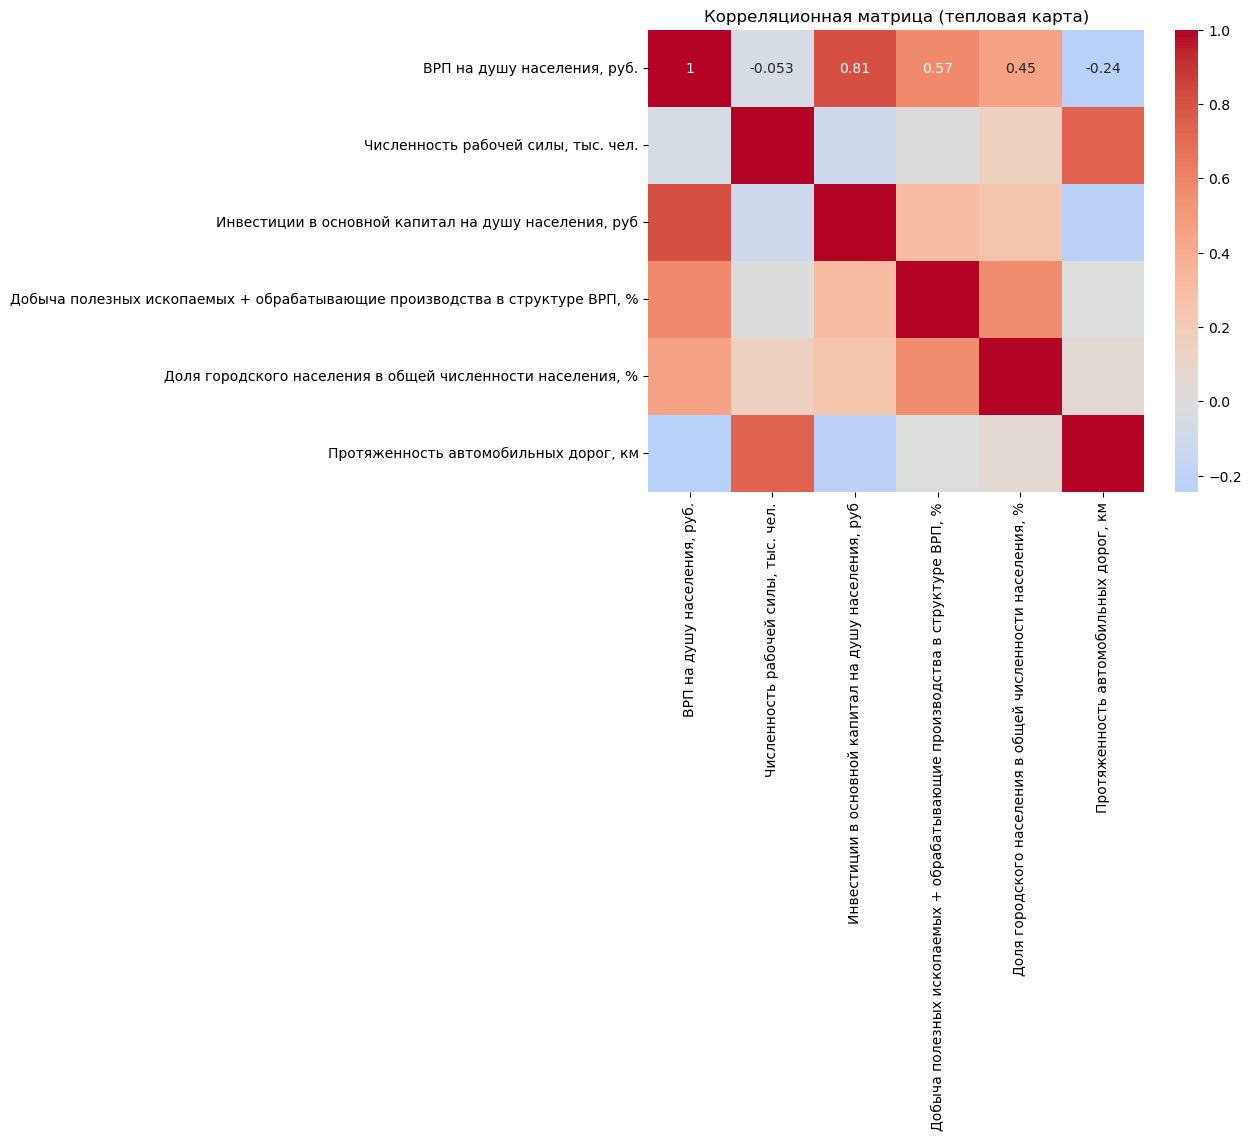

In [13]:
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Корреляционная матрица (тепловая карта)")
plt.show()

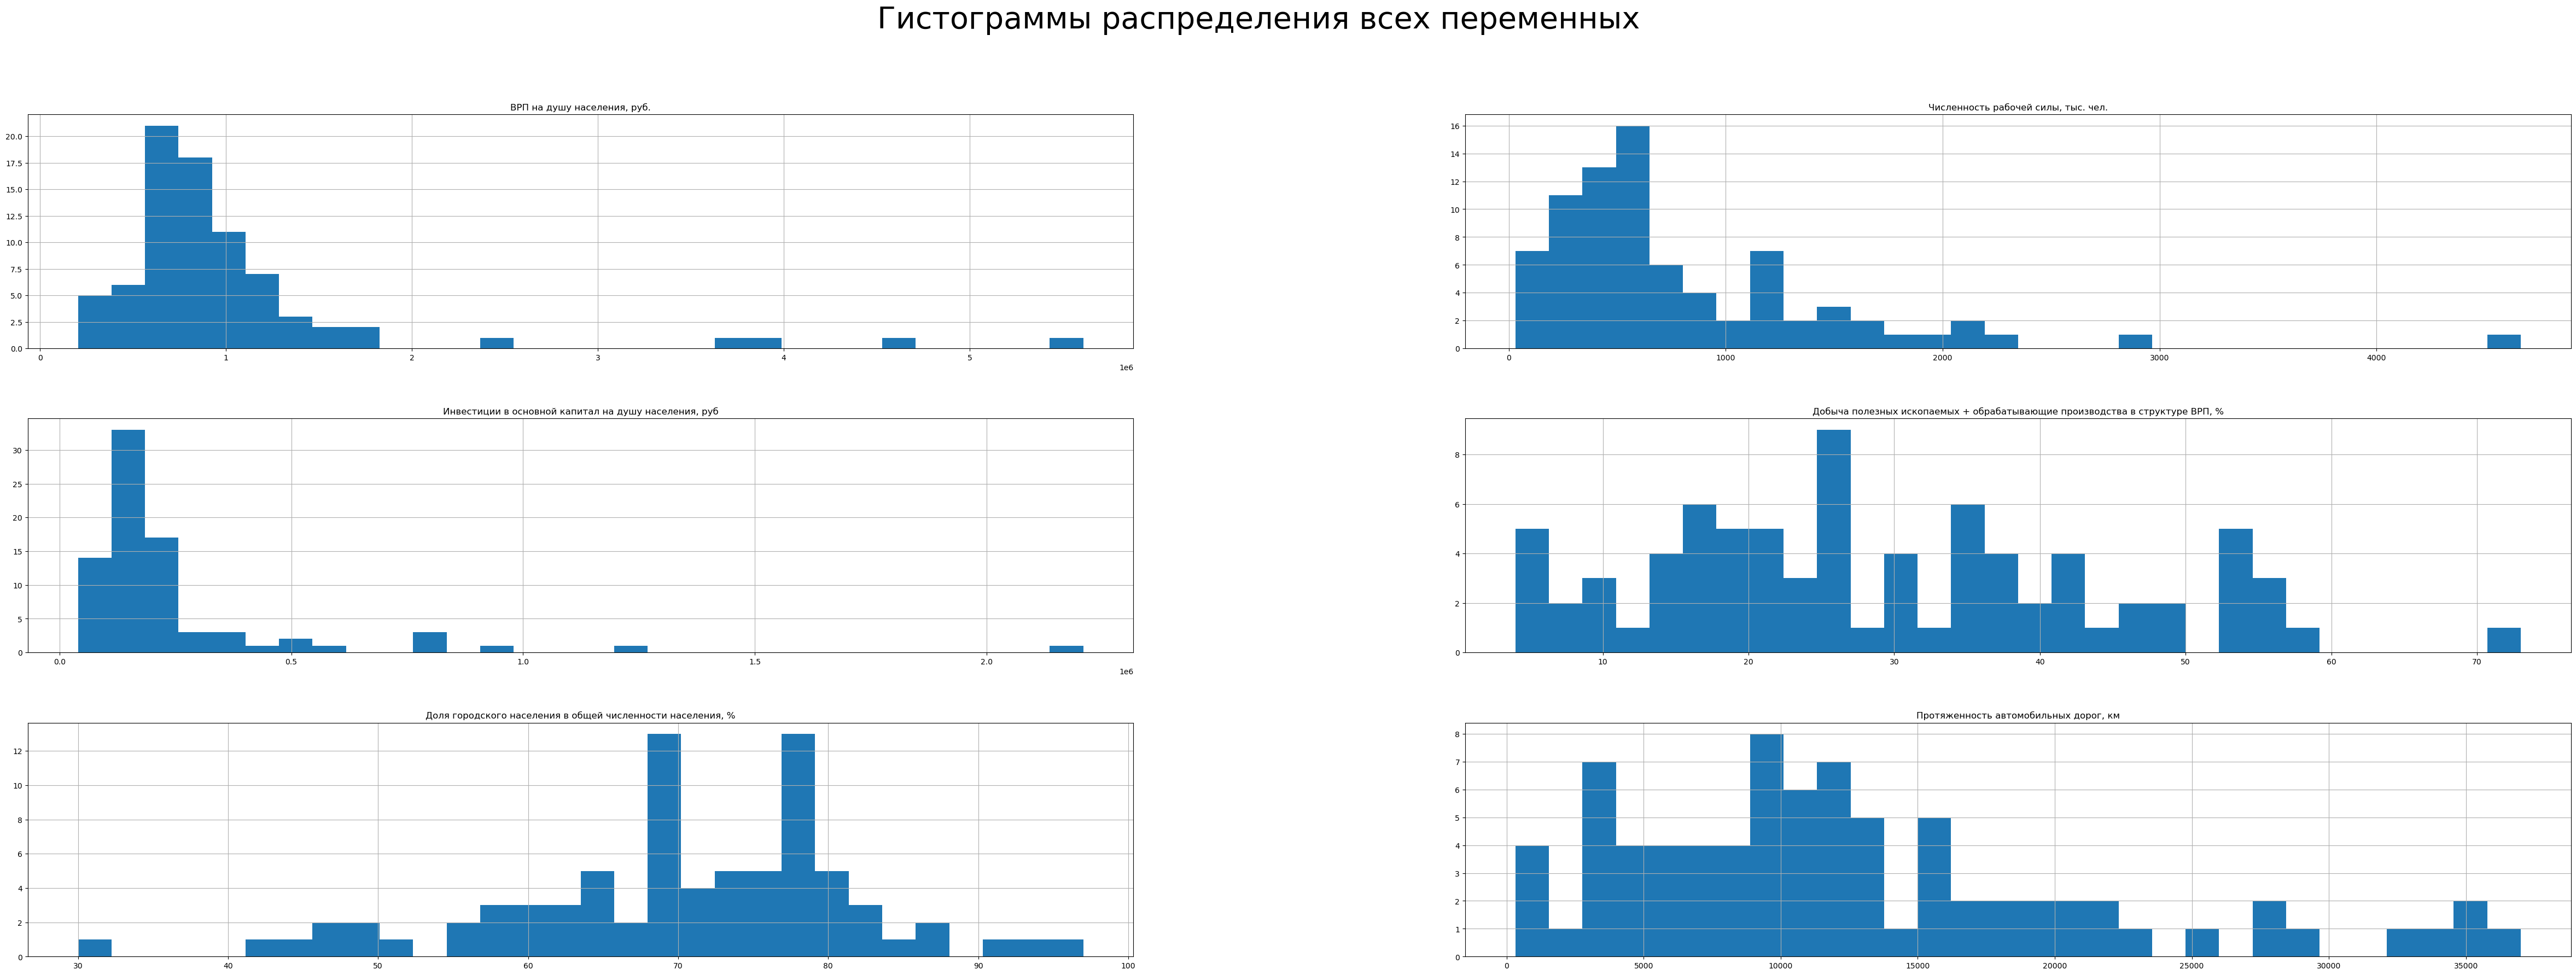

In [14]:
df.hist(bins=30, figsize=(60, 20))
plt.suptitle("Гистограммы распределения всех переменных", fontsize=40)
plt.show()

In [15]:
df['ВРП_на_душу_log'] = np.log1p(df['ВРП на душу населения, руб.']).clip(lower=0)
df['Численность_работников_log'] = np.log1p(df['Численность рабочей силы, тыс. чел.']).clip(lower=0)
df['Инвестиции_на_душу_log'] = np.log1p(df['Инвестиции в основной капитал на душу населения, руб']).clip(lower=0)
df['Протяженность_дорог_log'] = np.log1p(df['Протяженность автомобильных дорог, км']).clip(lower=0)

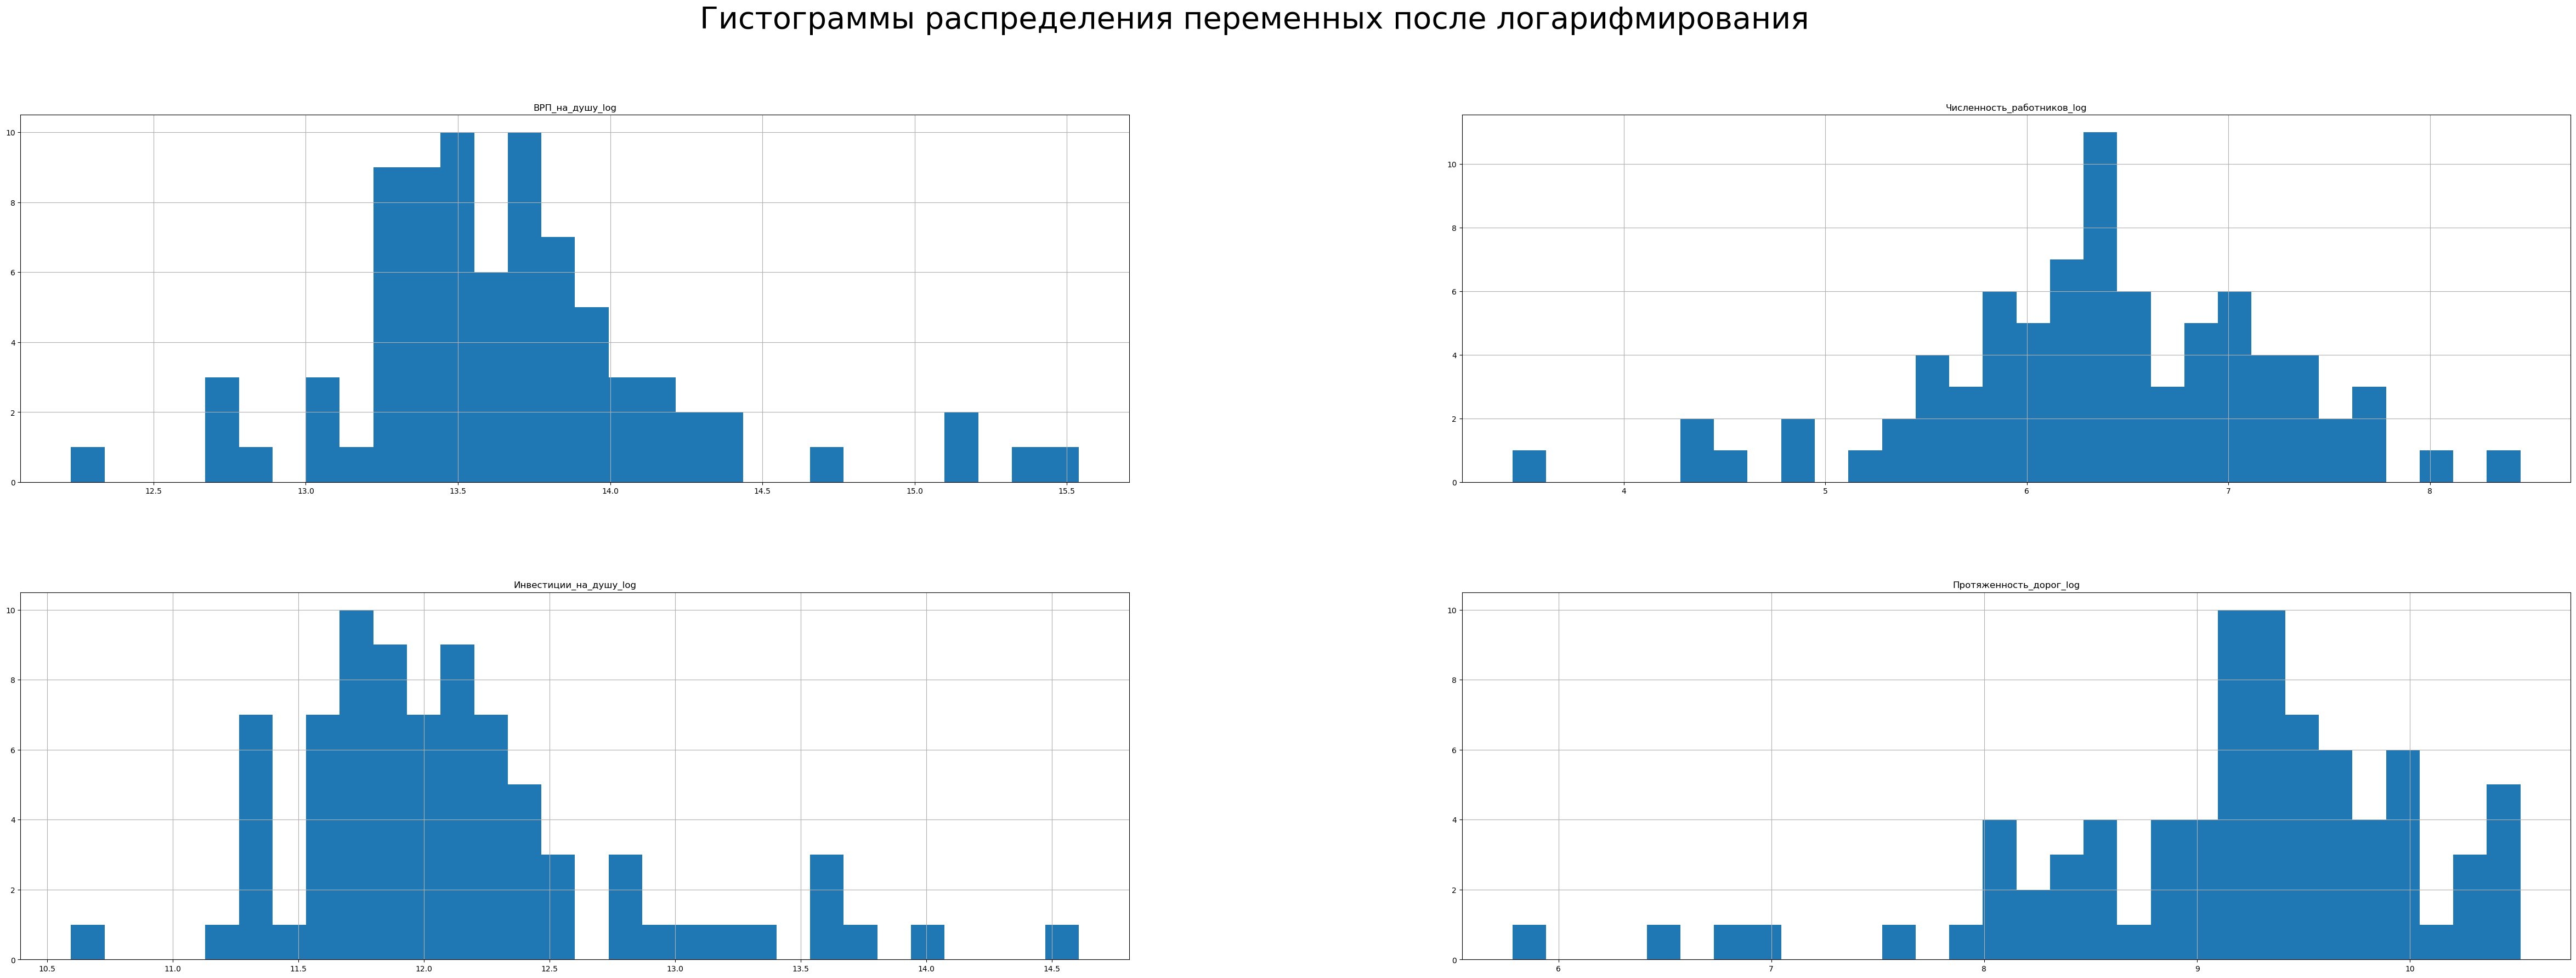

In [16]:
df_hist = pd.DataFrame()
df_hist['ВРП_на_душу_log'] = df['ВРП_на_душу_log']
df_hist['Численность_работников_log'] = df['Численность_работников_log']
df_hist['Инвестиции_на_душу_log'] = df['Инвестиции_на_душу_log']
df_hist['Протяженность_дорог_log'] = df['Протяженность_дорог_log']
df_hist.hist(bins=30, figsize=(60, 20))
plt.suptitle("Гистограммы распределения переменных после логарифмирования", fontsize=40)
plt.show()

## Обычный МНК

In [17]:
y_1 = df['ВРП_на_душу_log']

X_1 = df[['Численность_работников_log', 'Инвестиции_на_душу_log', 'Добыча полезных ископаемых + обрабатывающие производства в структуре ВРП, %', 'Доля городского населения в общей численности населения, %']]

X_1 = sm.add_constant(X_1)
model_1 = sm.OLS(y_1, X_1).fit()
print(model_1.summary())
print(model_1.params.round(2))

                            OLS Regression Results                            
Dep. Variable:        ВРП_на_душу_log   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     124.5
Date:                Sun, 24 May 2026   Prob (F-statistic):           2.60e-32
Time:                        21:02:34   Log-Likelihood:                 15.563
No. Observations:                  80   AIC:                            -21.13
Df Residuals:                      75   BIC:                            -9.217
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                                                                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

In [18]:
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data['Variable'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

vif_results = calculate_vif(X_1)
print(vif_results)

                                            Variable         VIF
0                                              const  462.171566
1                         Численность_работников_log    1.080811
2                             Инвестиции_на_душу_log    1.342368
3  Добыча полезных ископаемых + обрабатывающие пр...    1.592078
4  Доля городского населения в общей численности ...    1.563484


In [19]:
from statsmodels.stats.diagnostic import linear_reset
from scipy import stats
from scipy.stats import chi2

## Модель 2SLS

In [20]:
from linearmodels.iv import IV2SLS

y_2sls = df['ВРП_на_душу_log']
y_iv = y_2sls

exog_vars = ['Численность_работников_log', 
             'Добыча полезных ископаемых + обрабатывающие производства в структуре ВРП, %', 'Доля городского населения в общей численности населения, %']
endog_var = 'Инвестиции_на_душу_log'
instrument_var = 'Протяженность_дорог_log'
exog_iv = sm.add_constant(df[exog_vars])
endog_iv = df[[endog_var]]
instruments_iv = df[[instrument_var]]

# Модель А — 2SLS с классическими стандартными ошибками
model_A = IV2SLS(y_iv, exog_iv, endog_iv, instruments_iv).fit(cov_type='unadjusted')
print(model_A.first_stage.summary)
print(model_A.summary)

                                   First Stage Estimation Results                                   
                                                                              Инвестиции_на_душу_log
----------------------------------------------------------------------------------------------------
R-squared                                                                                     0.3505
Partial R-squared                                                                             0.1281
Shea's R-squared                                                                              0.1281
Partial F-statistic                                                                           11.754
P-value (Partial F-stat)                                                                      0.0010
Partial F-stat Distn                                                                         F(1,75)
=============================================================================            ==

In [21]:
X_hausman = X_1.copy()
X_first_stage = df[exog_vars + [instrument_var]]
X_first_stage = sm.add_constant(X_first_stage)
first_stage = sm.OLS(df[endog_var], X_first_stage).fit()
df['Инвестиции_предсказанные'] = first_stage.fittedvalues
residuals_first_stage = df[endog_var] - df['Инвестиции_предсказанные']
X_hausman['residuals_first_stage'] = residuals_first_stage

hausman_model = sm.OLS(y_2sls, X_hausman).fit()
hausman_test_stat = hausman_model.params['residuals_first_stage']
hausman_pvalue = hausman_model.pvalues['residuals_first_stage']

print(f"Коэффициент при остатках: {hausman_test_stat:.6f}")
print(f"P-value: {hausman_pvalue:.6f}")

Коэффициент при остатках: -0.267237
P-value: 0.020340


# Проверка на возможную гетероскедастичность

In [22]:
from statsmodels.stats.diagnostic import het_breuschpagan, het_white

# Тесты применяются к остаткам OLS-модели model_1 (см. ячейку с первой моделью)
bp_test = het_breuschpagan(model_1.resid, X_1)
white_test = het_white(model_1.resid, X_1)

print("H0: ошибки гомоскедастичны | H1: есть гетероскедастичность\n")

print("Тест Бройша-Пагана:")
print(f"  LM-статистика = {bp_test[0]:.4f}")
print(f"  p-value       = {bp_test[1]:.4f}")
print(f"  F-статистика  = {bp_test[2]:.4f}")
print(f"  p-value (F)   = {bp_test[3]:.4f}")
print(f"  Вывод: {'H0 отвергается - есть гетероскедастичность' if bp_test[1] < 0.05 else 'H0 не отвергается - гетероскедастичность не обнаружена'}\n")

print("Тест Уайта:")
print(f"  LM-статистика = {white_test[0]:.4f}")
print(f"  p-value       = {white_test[1]:.4f}")
print(f"  F-статистика  = {white_test[2]:.4f}")
print(f"  p-value (F)   = {white_test[3]:.4f}")
print(f"  Вывод: {'H0 отвергается - есть гетероскедастичность' if white_test[1] < 0.05 else 'H0 не отвергается - гетероскедастичность не обнаружена'}\n")

H0: ошибки гомоскедастичны | H1: есть гетероскедастичность

Тест Бройша-Пагана:
  LM-статистика = 4.4626
  p-value       = 0.3470
  F-статистика  = 1.1077
  p-value (F)   = 0.3593
  Вывод: H0 не отвергается - гетероскедастичность не обнаружена

Тест Уайта:
  LM-статистика = 33.6116
  p-value       = 0.0023
  F-статистика  = 3.3641
  p-value (F)   = 0.0004
  Вывод: H0 отвергается - есть гетероскедастичность



Так как гетероскедастичность обнаружена, проводим 2SLS со стандартными робастными ошибками

In [23]:
# Модель Б — 2SLS с робастными стандартными ошибками
model_B = IV2SLS(y_iv, exog_iv, endog_iv, instruments_iv).fit(cov_type='robust')
print(model_B.first_stage.summary)
print(model_B.summary)

                                   First Stage Estimation Results                                   
                                                                              Инвестиции_на_душу_log
----------------------------------------------------------------------------------------------------
R-squared                                                                                     0.3505
Partial R-squared                                                                             0.1281
Shea's R-squared                                                                              0.1281
Partial F-statistic                                                                           15.122
P-value (Partial F-stat)                                                                      0.0001
Partial F-stat Distn                                                                         chi2(1)
=============================================================================            ==

In [24]:
model_B.wooldridge_regression

Wooldridge's regression test of exogeneity
H0: Endogenous variables are exogenous
Statistic: 5.3464
P-value: 0.0208
Distributed: chi2(1)
WaldTestStatistic, id: 0x24f929ec490